2026-01-04 12:59:42.730077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767531582.903173      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767531582.957090      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767531583.380716      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767531583.380757      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767531583.380760      24 computation_placer.cc:177] computation placer alr

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Number of classes: 38


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767531620.776452      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Training Model A (Simple CNN)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3


I0000 00:00:1767531624.992199      81 service.cc:152] XLA service 0x7fb338005980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767531624.992237      81 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767531625.412042      81 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1358 ━━━━━━━━━━━━━━━━━━━━ 2:23:22 6s/step - accuracy: 0.0000e+00 - loss: 3.6004

I0000 00:00:1767531629.420330      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 765s 559ms/step - accuracy: 0.5002 - loss: 1.8724 - val_accuracy: 0.8187 - val_loss: 0.5667
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 587s 432ms/step - accuracy: 0.8468 - loss: 0.4957 - val_accuracy: 0.8857 - val_loss: 0.3605
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 568s 418ms/step - accuracy: 0.8914 - loss: 0.3341 - val_accuracy: 0.9124 - val_loss: 0.2704
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training Model B (Transfer Learning)...
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 598s 432ms/step - accuracy: 0.7883 - loss: 0.7829 - val_accuracy: 0.9200 - val_loss: 0.2458

Evaluating Transfer Learning Model...
340/340 ━━━━━━━━━━━━━━━━━━━━ 123s 350ms/step

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.82      0.86       126
                                 Apple___Black_rot       0.77      0.98      0.87       124
             

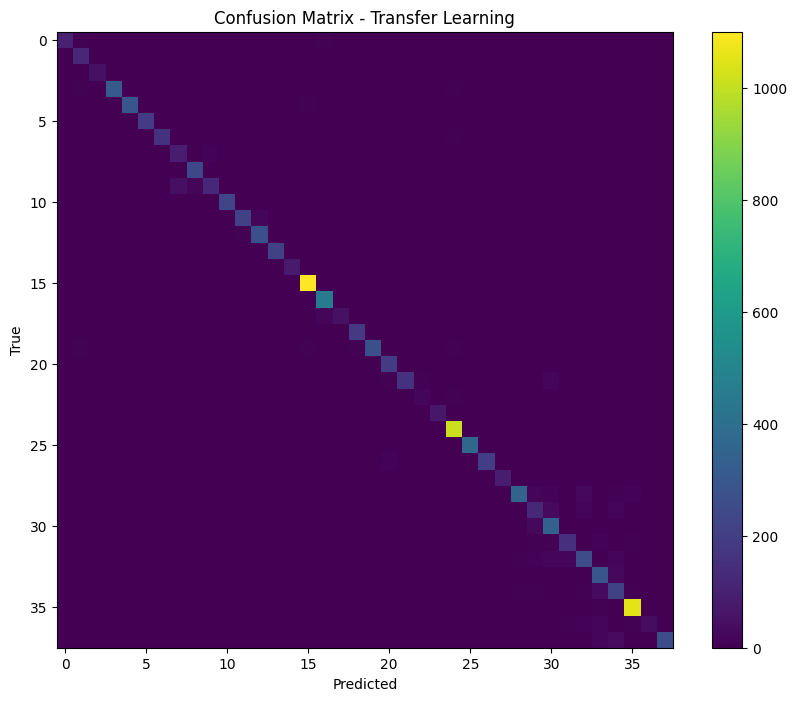


Model Comparison:
Simple CNN Final Val Accuracy: 0.9124
Transfer Learning Final Val Accuracy: 0.9200


In [1]:
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from sklearn.metrics import confusion_matrix, classification_report
# import numpy as np
# import matplotlib.pyplot as plt
# import os

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import os
# =========================
# 1. CONFIGURATION
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_CNN = 3
EPOCHS_TL = 1

DATASET_DIR = "/kaggle/input/plantvillage-dataset/color"  
# For Colab example:
# DATASET_DIR = "/content/plantvillage/PlantVillage"

# =========================
# 2. DATA LOADING & PREPROCESSING
# =========================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print("Number of classes:", NUM_CLASSES)

# =========================
# 3. MODEL A: SIMPLE CNN
# =========================
model_a = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_a.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Model A (Simple CNN)...")
history_a = model_a.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_CNN
)

# =========================
# 4. MODEL B: TRANSFER LEARNING (MobileNetV2)
# =========================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Freeze backbone

model_b = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_b.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Model B (Transfer Learning)...")
history_b = model_b.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_TL
)

# =========================
# 5. EVALUATION
# =========================
print("\nEvaluating Transfer Learning Model...")

val_preds = model_b.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.title("Confusion Matrix - Transfer Learning")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# 6. COMPARISON SUMMARY
# =========================
print("\nModel Comparison:")
print(f"Simple CNN Final Val Accuracy: {history_a.history['val_accuracy'][-1]:.4f}")
print(f"Transfer Learning Final Val Accuracy: {history_b.history['val_accuracy'][-1]:.4f}")
